The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ranging from pixel 60 140

=== START TRAINING ===

Norma iniziale chain[98]: 1.0000000000000022
DEBUG GRADIENTE - Ratio Aggiornamento/Peso: 4.78e-01

--- DIAGNOSTICA STEP 0 ---
Sito Attivo: 98 | Direzione: 1
Norme Ambienti: L=1.00e+00, R=1.00e+00
Logits: max=0.10, min=-0.06
Norma Gradiente G: 9.57e-01
Probabilità classe target (7): 0.0925
Predizione: 3 (Target: 7)
DEBUG GRADIENTE - Ratio Aggiornamento/Peso: 4.86e-01

--- DIAGNOSTICA STEP 100 ---
Sito Attivo: 99 | Direzione: 1
Norme Ambienti: L=1.00e+00, R=1.00e+00
Logits: max=0.21, min=-0.21
Norma Gradiente G: 9.55e-01
Probabilità classe target (6): 0.0950
Predizione: 2 (Target: 6)
DEBUG GRADIENTE - Ratio Aggiornamento/Peso: 4.69e-01

--- DIAGNOSTICA STEP 200 ---
Sito Attivo: 100 | Direzione: 1
Norme Ambienti: L=1.00e+00, R=1.00e+00
Logits: max=0.12, min=-0.12
Norma Gradiente G: 9.40e-01
Probabilità classe target (4): 0.1080
Predizione: 4 (Target: 4

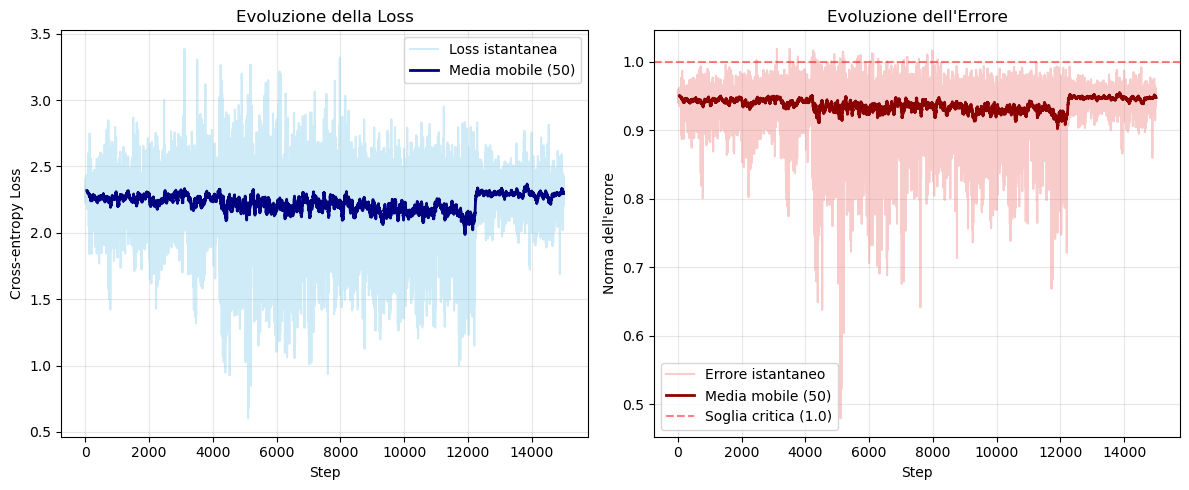


=== TEST SU CAMPIONE CASUALE ===
Label reale: 6
Predizione: 1

Probabilità per classe:


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import mappixels, onehot, get_active_pixels, downsample_images
from src.model import init_single_tensor, contr_lr_tens, contrfin, sweeping, shift_label, update_full_R_cache
from src.utils import plot_saliency_map

# ============================================================================
# MODEL PARAMETERS
# ============================================================================
M = 40                                    # Bond dimension
L = 196                                   # Pixel number (14x14)
initpos = L // 2                          # Starting position (98)
numclass = 10                             # 10 classes MNIST
nimg = 5000                                # Image number per training
errbuff = 50                              # Buffer error(for average error)

# Gradient descent parameters
learnrate = 0.5                       # Learning rate
batchsize = 100                             # Batch size

# Sweeping parameters
dir_sweep = 1                             # Starting direction (to the right)
imax = 140                                # Right limit
imin = 60                                # Left limit

# ============================================================================
# DATA LOADING
# ============================================================================
pathX = os.path.join('..', 'data', 'X_mnist.npy')
pathy = os.path.join('..', 'data', 'y_mnist.npy')

X = np.load(pathX)[:nimg]
y = np.load(pathy)[:nimg]

X=downsample_images(X)
X= X.astype(np.float32) / 255.0

#imin_safe, imax_safe= get_active_pixels(X)
#imin = max(imin_safe, 10)  # Non scendere sotto il sito 10
#imax = min(imax_safe, 180)
print("Ranging from pixel",imin, imax)

# ============================================================================
# MPS CHAIN INITIALIZING
# ============================================================================
actpos = initpos  # Starting active position (chain center)
chain = []

for i in range(L):
    dL = 1 if i == 0 else M
    dR = 1 if i == L-1 else M
    
    if i == initpos:
        t = init_single_tensor(dL, 2, dR, numclass)
    else:
        t = init_single_tensor(dL, 2, dR)
    
    chain.append(t)

# 2. CANONIZZAZIONE QR (Versione Corretta e Normalizzata)
for i in range(0, initpos):
    dL, dP, dR = chain[i].shape[:3]
    mat = chain[i].reshape(dL * dP, dR)
    Q, R = np.linalg.qr(mat)
    
    # NORMALIZZAZIONE: Impedisce il crollo della norma
    R_norm = np.linalg.norm(R)
    if R_norm > 0:
        R /= R_norm 

    chain[i] = Q.reshape(dL, dP, -1)
    if chain[i+1].ndim == 3:
        chain[i+1] = np.einsum('ab, bcd -> acd', R, chain[i+1])
    else:
        chain[i+1] = np.einsum('ab, bcdl -> acdl', R, chain[i+1])

for i in range(L - 1, initpos, -1):
    dL, dP, dR = chain[i].shape[:3]
    mat = chain[i].reshape(dL, dP * dR).T
    Q, R = np.linalg.qr(mat)
    
    # NORMALIZZAZIONE
    R_norm = np.linalg.norm(R)
    if R_norm > 0:
        R /= R_norm

    chain[i] = Q.T.reshape(-1, dP, dR)
    RT = R.T
    if chain[i-1].ndim == 3:
        chain[i-1] = np.einsum('abc, cd -> abd', chain[i-1], RT)
    else:
        chain[i-1] = np.einsum('abcl, cd -> abdl', chain[i-1], RT)

# INFINE: Forza il tensore centrale ad avere norma 1
chain[initpos] /= np.linalg.norm(chain[initpos])

rms_cache = [np.zeros_like(site) for site in chain]
decay_rate = 0.9  # Tipico valore per RMSProp (rho)
eps = 1e-8        # Per evitare divisioni per zero
 

# ============================================================================
# TRAINING VARIABLES INITIALIZATION 
# ============================================================================
err = np.zeros(numclass, dtype=np.float64)    # label vector - onehottarget
errvec= []                                      # Contains error-vec norms
Gacc = np.zeros_like(chain[actpos])           # Cumulated gradient
losses = []                                   # Loss list
saliency_map=np.zeros(L, dtype=np.float64)
# ============================================================================
# TRAINING LOOP
# ============================================================================
print("\n=== START TRAINING ===\n")
print(f"Norma iniziale chain[98]: {np.linalg.norm(chain[98])}")

L_cache = [None] * L
R_cache = [None] * L

for epoch in range(3):

    indices = np.arange(nimg)
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]

    for i in range(nimg):
        imgraw = X[i]
        label = y[i]
        imgvec = mappixels(imgraw)

        # A: Inizializza l'ambiente sinistro al bordo (se sei all'inizio dell'immagine)
        # In un vero sweep progressivo, L_cache si aggiorna passo dopo passo.
        # Per ora, per semplicità, resettiamo L al bordo 0.
        l_val = np.array([1.0], dtype=np.float64)
        for m in range(actpos):
            matrix_m = np.einsum('lpr, p -> lr', chain[m], imgvec[m])
            l_val = l_val @ matrix_m
            l_val /= (np.linalg.norm(l_val) + 1e-16)
        
        # B: Pre-calcola la R_cache per questa immagine (da actpos in poi)
        update_full_R_cache(chain, imgvec)
        
        # C: Recupera gli ambienti per il sito attivo
        lchain = l_val
        rchain = R_cache[actpos]
    

        dL, dP, dR, dS = chain[actpos].shape
        if lchain.shape[0] != dL or rchain.shape[0] != dR:
            print(f"\n❌ ERRORE DIMENSIONI RILEVATO!")
            print(f"Sito Attivo (actpos): {actpos}")
            print(f"Shape Tensore Centrale: {chain[actpos].shape}")
            print(f"Lvec (Ambiente Sinistro): {lchain.shape} -> Dovrebbe essere ({dL},)")
            print(f"Rvec (Ambiente Destro): {rchain.shape} -> Dovrebbe essere ({dR},)")
    
            # Controlliamo i vicini
            if actpos > 0: print(f"Shape tensore a sinistra: {chain[actpos-1].shape}")
            if actpos < L-1: print(f"Shape tensore a destra: {chain[actpos+1].shape}")
    
            raise ValueError("Incoerenza dimensionale tra ambienti e sito attivo.")
    
        # --- Step 3: Calculating output and softmax ---
        probs, logits = contrfin(lchain, rchain, chain[actpos], imgvec[actpos])


        # --- Step 4: Calcolating error and loss ---
        target_onehot = onehot(label, numclass)
        err = probs - target_onehot
        errnorm = np.linalg.norm(err)
        errvec.append(errnorm)
        
        # Cross-entropy loss
        loss = - np.sum(target_onehot * np.log(probs + 1e-12))
        if loss > 10:
            print(f"WARNING: High loss ({loss:.2f}), G clipping e learn-rate reduction")
        #   learnrate *= 0.8  # learn rate reduction 

        losses.append(loss)
    
        # --- PASSO 5: Calcolo gradiente locale (Equazione articolo) ---
        # G = left ⊗ p_center ⊗ right ⊗ err
        G = np.einsum('l,p,r,s->lprs', lchain, imgvec[actpos], rchain, err)
        normG = np.linalg.norm(G)

        if i % 100 == 0:
            # Quanto è "grande" l'aggiornamento rispetto al peso esistente?
            ratio = np.linalg.norm(learnrate * G) / np.linalg.norm(chain[actpos])
            print(f"DEBUG GRADIENTE - Ratio Aggiornamento/Peso: {ratio:.2e}")
            norm_L = np.linalg.norm(lchain)
            norm_R = np.linalg.norm(rchain)
            max_logit = np.max(np.abs(logits))
            norm_G = np.linalg.norm(G)
    
            print(f"\n--- DIAGNOSTICA STEP {i} ---")
            print(f"Sito Attivo: {actpos} | Direzione: {dir_sweep}")
            print(f"Norme Ambienti: L={norm_L:.2e}, R={norm_R:.2e}")
            print(f"Logits: max={max_logit:.2f}, min={np.min(logits):.2f}")
            print(f"Norma Gradiente G: {norm_G:.2e}")
            print(f"Probabilità classe target ({label}): {probs[label]:.4f}")
            print(f"Predizione: {np.argmax(probs)} (Target: {label})")
    
            # Verifica se i logits sono esplosi a causa del *10
            if max_logit > 30:
                print("⚠️ ATTENZIONE: Logits troppo alti, la softmax è saturata!")
        #saliency_map[actpos]+= normG
        #if i%500==0 or i==nimg:
        # plot_saliency_map(saliency_map)
         #saliency_map.fill(0)

        #DEBUG---------
        #if i%100== 0:
        #   print("norma del gradiente allo step:",i, normG)
        if norm_G > 0.1: # Limite severo per stabilizzare
            G = G * (0.1 / norm_G)

        #if normG > 1.0:
         #   G = G / normG
        Gacc += G
    
        # All'interno del loop delle immagini (i in range(nimg))
# ... calcolo gradiente su Gacc ...

        if (i + 1) % batchsize == 0:

            # 1. Media del gradiente sul batch
            Gacc = Gacc / batchsize


            if rms_cache[actpos].shape != Gacc.shape:
                rms_cache[actpos] = np.zeros_like(Gacc)
            # === LOGICA RMSProp ===
            # 2. Aggiornamento della media mobile dei quadrati dei gradienti (solo per il sito attivo)
            rms_cache[actpos] = decay_rate * rms_cache[actpos] + (1 - decay_rate) * (Gacc**2)

            # 3. Calcolo del gradiente adattivo
            # Gacc viene diviso per la sua "volatilità" storica. 
            # Se il gradiente è stato quasi nullo, questo termine lo amplifica.
            grad_adattivo = Gacc / (np.sqrt(rms_cache[actpos]) + eps)

            # 4. Aggiornamento del tensore
            old_t = chain[actpos].copy()
            chain[actpos] -= learnrate * grad_adattivo

            # === NORMALIZZAZIONE POST-AGGIORNAMENTO ===
            # Fondamentale: dopo lo spostamento dei pesi, riporta il sito a norma 1.0
            # per evitare che gli ambienti (lchain/rchain) divergano o collassino.
            chain[actpos] /= (np.linalg.norm(chain[actpos]) + 1e-16)

            # DEBUG Diagnostico
            if i % 500 == 0 and i > 0:
                diff = np.linalg.norm(chain[actpos] - old_t)
                print(f"DEBUG - Tensor Update Delta (RMSProp): {diff:.2e}")
                print(f"DEBUG - Grad Norm (Original): {np.linalg.norm(Gacc):.2e}")

            # --- SWEEPING LOGIC ---
            next_pos, next_dir = sweeping(actpos, dir_sweep, imin, imax)

            if next_pos != actpos:
                # Passaggio della label (SVD) al nuovo sito
                chain = shift_label(chain, actpos, dir_sweep, M, imin, imax)
                actpos = next_pos
                dir_sweep = next_dir
            else:
                # Rimbalzo al bordo
                dir_sweep = next_dir

    # 5. Reset del gradiente accumulato
    # Nota: usiamo np.zeros_like del NUOVO actpos perché la forma potrebbe cambiare 
    # se i bond dimensions non sono uniformi
            Gacc = np.zeros_like(chain[actpos])
   
    
    # --- PASSO 7: Monitoraggio ---
        if i % 500 == 0 and i > 0:
            t_norm = np.linalg.norm(chain[actpos])
            print(f"DEBUG - Grad Norm: {normG:.2e}, Tensor Norm: {t_norm:.2f}, Ratio: {normG/t_norm:.2e}")
            entropy = -np.sum(probs * np.log(probs + 1e-12))
            print(f"DEBUG - Entropy: {entropy:.4f} (Max: 2.30)")
            avg_loss = np.mean(losses[-500:])
            avg_err = np.mean(errvec[-500:])
            pred = np.argmax(probs)
            acc = (pred == label)
            print(f"Step {i:5d}: Loss = {avg_loss:.4f}, Err = {avg_err:.4f}, "
                f"Pred = {pred}, True = {label}, Corretto = {acc}")

        if i % 1000 == 0 and i > 0:
            learnrate *= 0.95  # Decadimento learning rate

# ============================================================================
# RISULTATI FINALI E VISUALIZZAZIONE
# ============================================================================
print("\n=== TRAINING COMPLETATO ===")
print(f"Loss media ultimi {errbuff} step: {np.mean(losses[-errbuff:]):.4f}")
print(f"Errore medio ultimi {errbuff} step: {np.mean(errvec[-errbuff:]):.4f}")

# Plot dei risultati
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(losses, color='skyblue', alpha=0.4, label='Loss istantanea')
if len(losses) >= 50:
    smooth_loss = np.convolve(losses, np.ones(50)/50, mode='valid')
    plt.plot(range(49, len(losses)), smooth_loss, 'navy', lw=2, label='Media mobile (50)')
plt.xlabel('Step')
plt.ylabel('Cross-entropy Loss')
plt.title('Evoluzione della Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Errore
plt.subplot(1, 2, 2)
plt.plot(errvec, color='lightcoral', alpha=0.4, label='Errore istantaneo')
if len(errvec) >= 50:
    smooth_err = np.convolve(errvec, np.ones(50)/50, mode='valid')
    plt.plot(range(49, len(errvec)), smooth_err, 'darkred', lw=2, label='Media mobile (50)')
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Soglia critica (1.0)')
plt.xlabel('Step')
plt.ylabel('Norma dell\'errore')
plt.title('Evoluzione dell\'Errore')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()